In [1]:
import csv
import sys
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np

In [2]:
SUBTYPE_NAME = {
    2:  "Multiple Scatering",
    10: "e Ionization",
    11: "eBrem",
    12: "photoelectric",
    13: "compton",
    14: "conversion",
    21: "ionIoni",
    22: "hIoni",
}

In [3]:
zbin, subtype, count = [],[],[]
with open('dominan_by_step.csv', newline='') as csvfile:
    reader = csv.DictReader(csvfile)  
    for row in reader:
        zbin.append(row["zbin"])
        subtype.append(int(row["subtype"]))
        count.append(float(row["count"]))

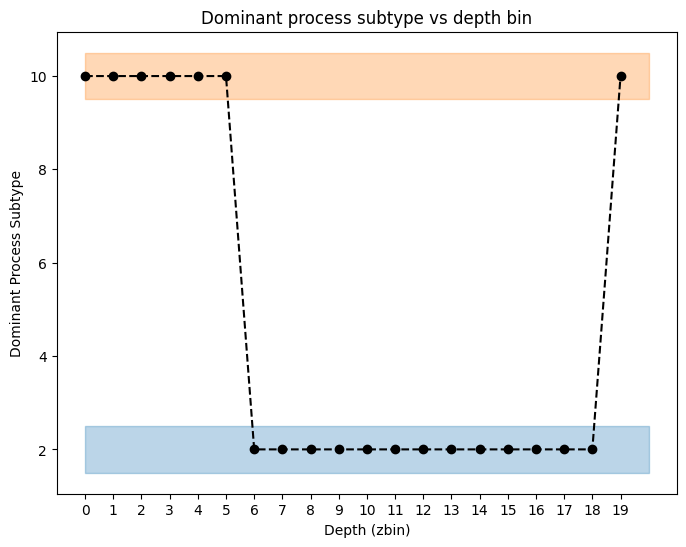

<Figure size 640x480 with 0 Axes>

In [4]:
x=np.array([0,0,20,20])
fig = plt.figure(figsize=(8, 6))

ax = fig.add_subplot()
plt.plot(zbin,subtype,'--o', color='k')
ax.fill_between(x, 1.5,2.5 , color='C0', alpha=0.3)
ax.fill_between(x, 9.5,10.5, color='C1', alpha=0.3)
ax.set_xlabel('Depth (zbin)')
ax.set_ylabel('Dominant Process Subtype')
plt.title("Dominant process subtype vs depth bin")
plt.show()
plt.savefig("dominant_subtype_by_depth.png", dpi=200)

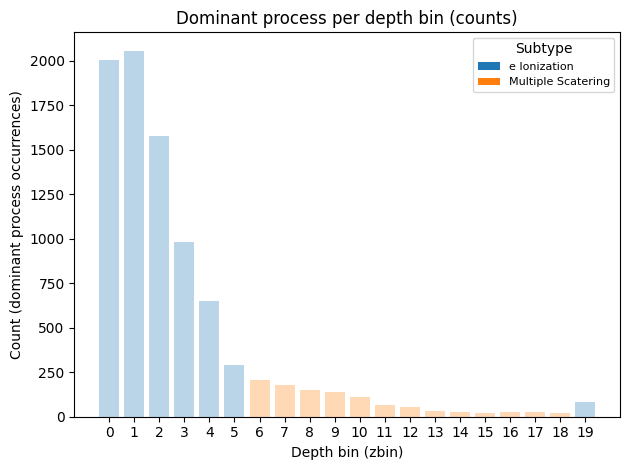

<Figure size 640x480 with 0 Axes>

In [5]:
# Subtype → color (asignar un color único a cada subtype)
unique_subtypes = list(set(subtype))
colors = {st: cm.tab10(i % 10) for i, st in enumerate(unique_subtypes)}

plt.figure()
plt.bar(zbin, count, alpha=0.3, color=[colors[st] for st in subtype])

# Opcional: leyenda con los nombres
for st in unique_subtypes:
    plt.bar(0, 0, color=colors[st],  label=SUBTYPE_NAME.get(st, str(st)))  # barras invisibles para la leyenda

plt.xlabel("Depth bin (zbin)")
plt.ylabel("Count (dominant process occurrences)")
plt.title("Dominant process per depth bin (counts)")
plt.legend(title="Subtype", fontsize=8)
plt.tight_layout()
plt.show()
plt.savefig("dominant_counts_by_depth.png", dpi=200)